In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import sys
sys.path.append("../utils")
from plotting_utils import format_top_3, plot_metric_grouped_by, plot_bio_vs_batch_correction,  plot_bio_vs_batch_correction_markers

In [2]:
%load_ext autoreload
%autoreload 2

In [7]:
# base_path = "/home/mila/m/myriam.lizotte/RF-MALI"
# mali_path = "/home/mila/m/myriam.lizotte/MALI"
# scratch_path = "/home/mila/m/myriam.lizotte/scratch/RF-MALI"

# save_name = f"real_batches" #dataset}".format(dataset = dataset_name)
# save_path = f"{scratch_path}/results/{save_name}"


# results_path = "/home/lizottem/RF-MALI/results"
results_path = "/NOBACKUP/lizottem/fosta/results"
exp_name = "real_batches_lung"
save_name = f"real_batches_lung/2026-05-01_01-25-45" #dataset}".format(dataset = dataset_name)
save_path = f"{results_path}/{save_name}"


create a new summary df based on aggregating the dfs in the n_comp subfolders (only needs to be ran once)

In [12]:
batches = ["1","2","3","4","5","6", "A1", "A2", "A3", "A4", "A5", "A6", "B1", "B2", "B3", "B4"]
batches = ["A1", "A2", "A3", "A4", "A5", "A6"]
seeds = [11784, 39041, 56089, 79121, 4386721]

all_results_df = pd.DataFrame()
for i1, batch1 in enumerate(batches):
    for i2, batch2 in enumerate(batches):
        if i1 >= i2:
            continue
    
        for seed in seeds:
            save_path_subfolder = f"{save_path}/{batch1}_{batch2}/seed_{seed}"
            try:
                df = pd.read_csv(f"{save_path_subfolder}/{exp_name}_results.csv")
            except FileNotFoundError:
                df = pd.DataFrame()
                print(f"File not found: {save_path_subfolder}/{exp_name}_results.csv")

            df["batch1"] = batch1
            df["batch2"] = batch2
            all_results_df = pd.concat([all_results_df, df], ignore_index=True)
                
all_results_df    
all_results_df.to_csv(f"{save_path}/{exp_name}_with_batches_results.csv", index=False)
                

File not found: /NOBACKUP/lizottem/fosta/results/real_batches_lung/2026-05-01_01-25-45/A1_A2/seed_39041/real_batches_lung_results.csv
File not found: /NOBACKUP/lizottem/fosta/results/real_batches_lung/2026-05-01_01-25-45/A1_A2/seed_4386721/real_batches_lung_results.csv
File not found: /NOBACKUP/lizottem/fosta/results/real_batches_lung/2026-05-01_01-25-45/A1_A3/seed_39041/real_batches_lung_results.csv
File not found: /NOBACKUP/lizottem/fosta/results/real_batches_lung/2026-05-01_01-25-45/A1_A3/seed_79121/real_batches_lung_results.csv
File not found: /NOBACKUP/lizottem/fosta/results/real_batches_lung/2026-05-01_01-25-45/A1_A3/seed_4386721/real_batches_lung_results.csv
File not found: /NOBACKUP/lizottem/fosta/results/real_batches_lung/2026-05-01_01-25-45/A1_A4/seed_39041/real_batches_lung_results.csv
File not found: /NOBACKUP/lizottem/fosta/results/real_batches_lung/2026-05-01_01-25-45/A1_A4/seed_4386721/real_batches_lung_results.csv
File not found: /NOBACKUP/lizottem/fosta/results/real_ba

In [12]:
save_name

'real_batches_lung/2026-04-26_23-27-42'

# Real batches data

In [13]:
# load results
exp_name = "real_batches_lung_with_batches"
results_df = pd.read_csv(f"{save_path}/{exp_name}_results.csv")


metric_type = results_df.loc[results_df["method"] == "Metric Type"]
metric_type = metric_type.drop(columns=['method']).drop_duplicates()
results_df = results_df.loc[results_df["method"] != "Metric Type"]


# # convert relevant columns to numeric
num_cols = results_df.columns.difference(['method', 'batch1', 'batch2'])
results_df[num_cols] = results_df[num_cols].apply(pd.to_numeric, errors='coerce')


# results_df = results_df.drop(0, axis = 0) # remove one run from debugging
# results_df.drop_duplicates(subset=['method'], keep='last', inplace=True)


# delete rows where n_components is NA
results_df = results_df.loc[~results_df["n_components"].isna()]


# remove n_components in the model column (it was just used to not overwrite adata, and it's already another column)
results_df["method"] = results_df["method"].str.replace(r'_\d+_components', '', regex=True)

In [6]:
# rename FOSTA PHATE t2 to FoSTA
results_df["method"] = results_df["method"].replace({"FoSTA_PHATE_t2": "FoSTA"})
results_df["method"] = results_df["method"].replace({"RFMALI_PHATE_t2": "RFMALI"})

methods_to_remove= ["RFMALI"]
results_df = results_df[~results_df["method"].isin(methods_to_remove)]

In [14]:
results_df

,seed,n_components,method,Isolated labels,Leiden NMI,Leiden ARI,KMeans NMI,KMeans ARI,Silhouette label,cLISI,...,Graph connectivity,PCR comparison,Batch correction,Bio conservation,Total,cell_cycle_score,time,memory,batch1,batch2
0,11784.0,2.0,Unintegrated,0.623492,0.856104,0.874786,0.690801,0.485286,0.665566,0.999839,...,0.906437,0.000000,0.462540,0.742268,0.630376,NaN,NaN,NaN,A1,A2
1,11784.0,2.0,Old FoSTA kerf t=2,0.621444,0.623065,0.390371,0.646032,0.471937,0.687793,1.000000,...,0.659486,0.928724,0.585994,0.634377,0.615024,0.694353,73.016186,235.021749,A1,A2
2,11784.0,2.0,Old FoSTA kerf t=auto,0.617091,0.610684,0.374799,0.674224,0.626001,0.678757,1.000000,...,0.697209,0.947625,0.585281,0.654508,0.626817,0.691237,141.143915,249.333890,A1,A2
3,11784.0,2.0,Old FoSTA gap t=2,0.543429,0.660371,0.523428,0.659270,0.582073,0.731165,1.000000,...,0.800164,0.997608,0.704605,0.671391,0.684676,0.855083,30.434055,206.833932,A1,A2
4,11784.0,2.0,Old FoSTA gap t=auto,0.482331,0.629202,0.428024,0.661842,0.569084,0.720423,0.999944,...,0.755169,0.996380,0.707111,0.641550,0.667775,0.782696,75.852679,242.136525,A1,A2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
840,56089.0,2.0,scVI,0.500000,0.540331,0.248597,0.556203,0.293261,0.539419,0.995135,...,0.849488,0.733664,0.696638,0.524707,0.593479,0.438486,237.882318,32.819140,A5,A6
841,56089.0,2.0,scANVI,0.500000,0.686460,0.400732,0.695420,0.475728,0.671201,1.000000,...,0.933222,0.816697,0.718986,0.632792,0.667269,0.722279,247.999348,35.483921,A5,A6
842,56089.0,2.0,Pamona,0.500000,0.500938,0.154844,0.491069,0.217350,0.500848,0.994206,...,0.783523,0.995051,0.587308,0.479894,0.522859,0.764943,177.393400,1345.425759,A5,A6
843,56089.0,2.0,KEMArbf,0.500000,0.551137,0.298648,0.738189,0.637730,0.634852,0.981612,...,0.880288,0.812131,0.720415,0.620310,0.660352,0.114671,1.170075,5.947765,A5,A6


# make plots

/home/mila/m/myriam.lizotte/RF-MALI/notebooks/../utils/plotting_utils.py:280: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  title=groupby_cols[1],


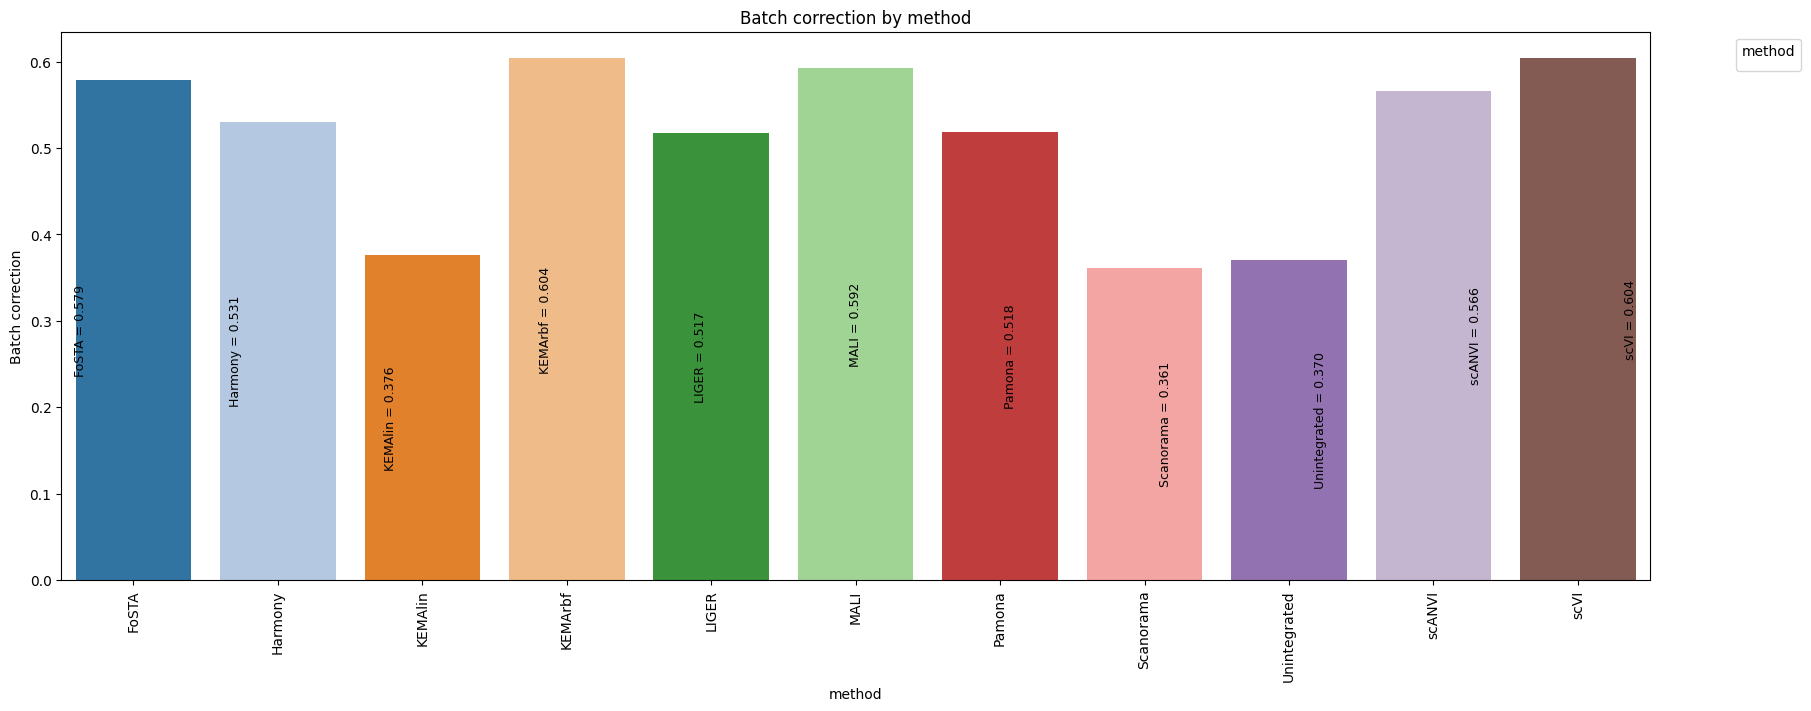

/home/mila/m/myriam.lizotte/RF-MALI/notebooks/../utils/plotting_utils.py:280: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  title=groupby_cols[1],


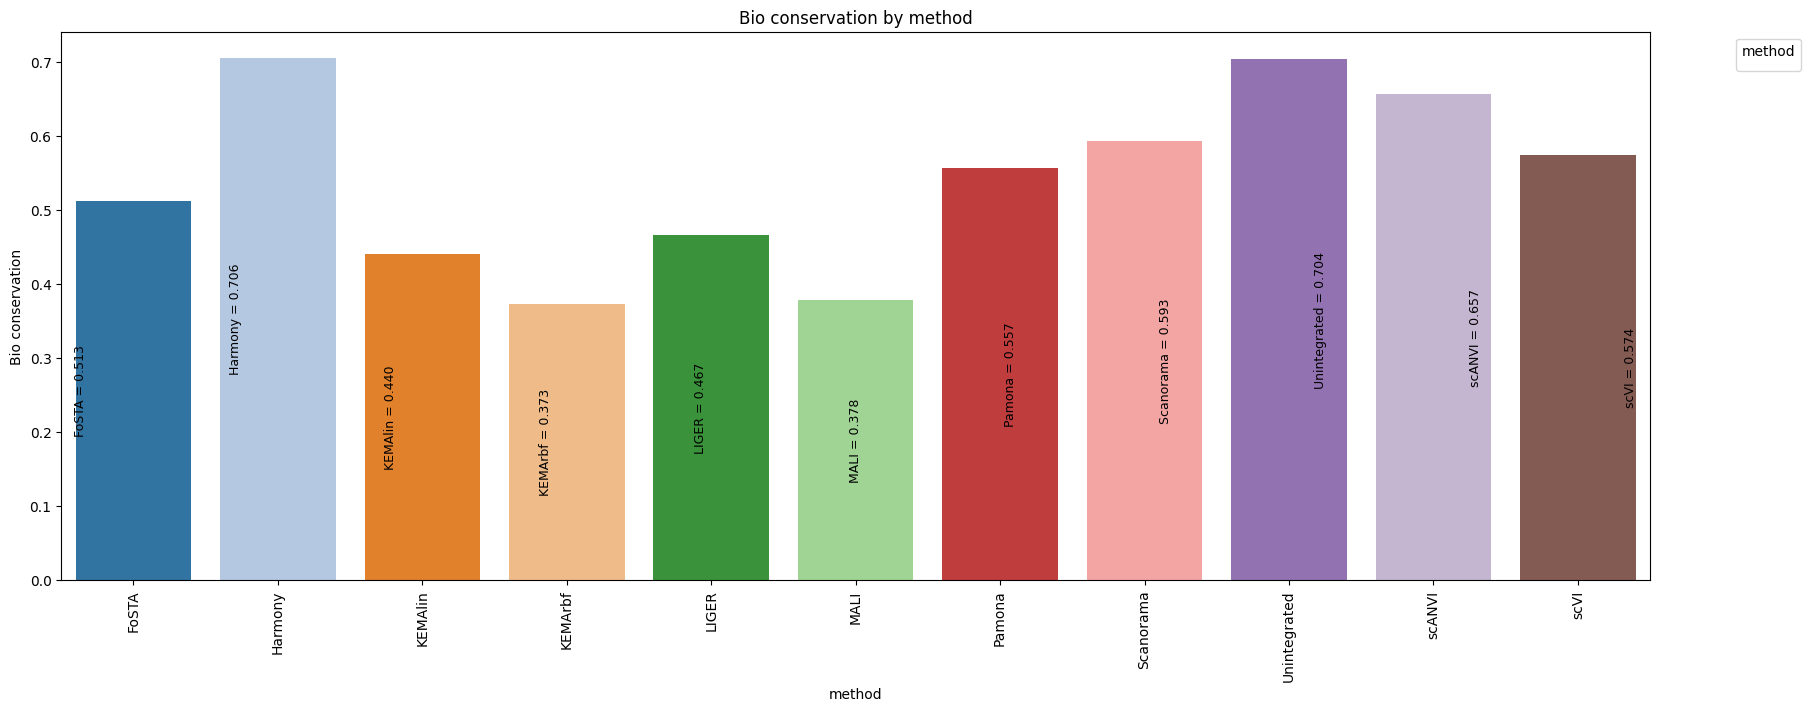

/home/mila/m/myriam.lizotte/RF-MALI/notebooks/../utils/plotting_utils.py:280: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  title=groupby_cols[1],


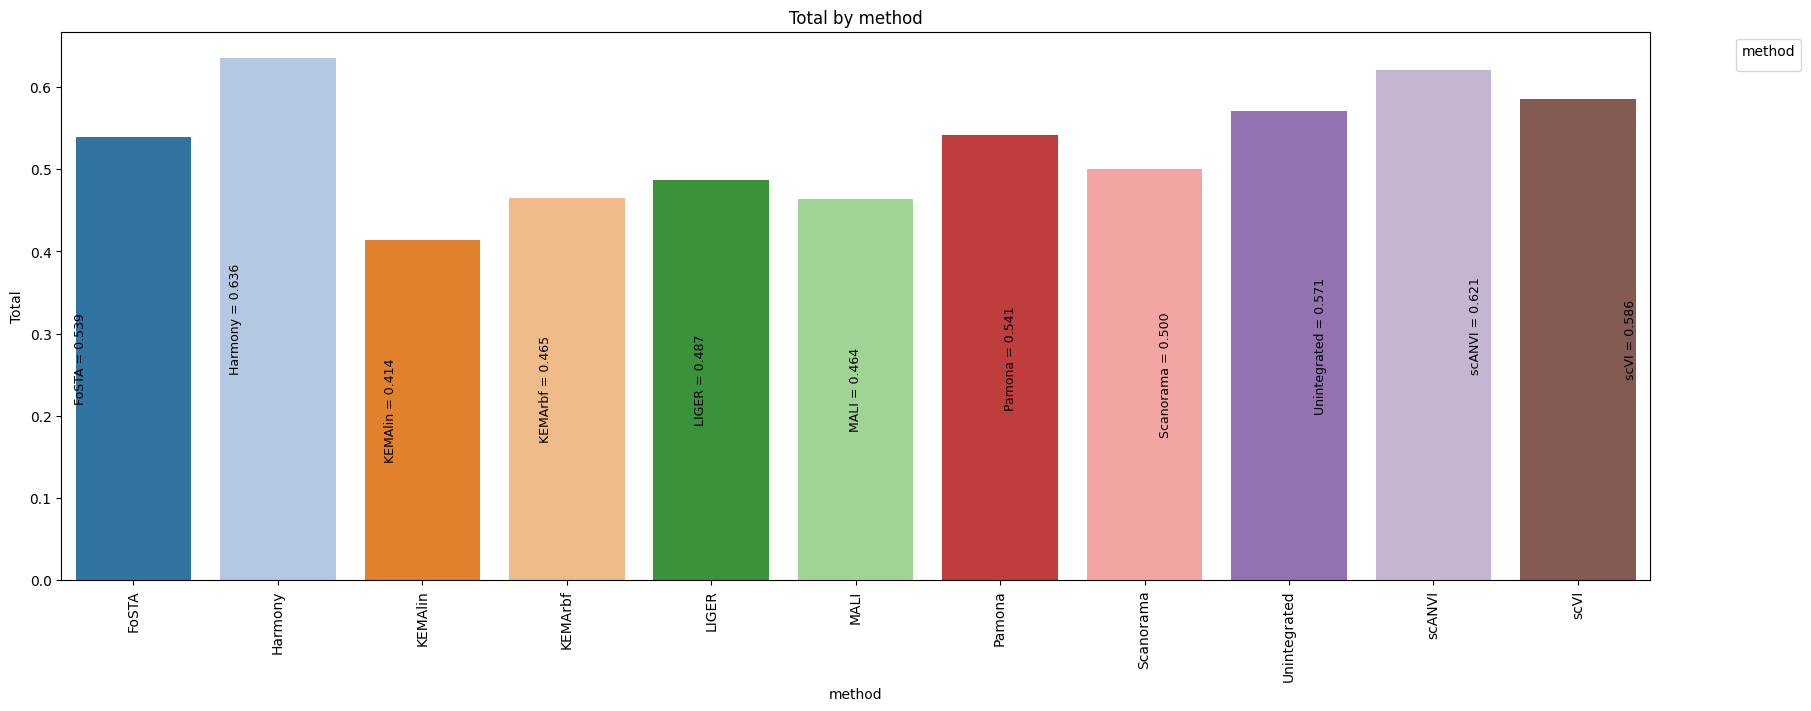

In [52]:
plot_metric_grouped_by(results_df, groupby_cols=["method"])

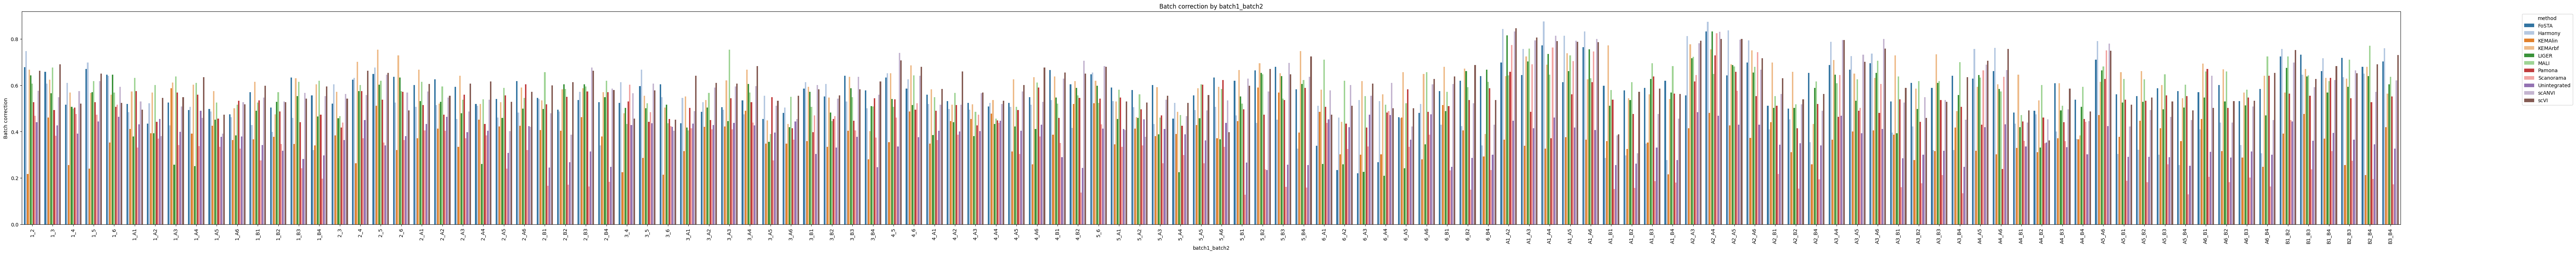

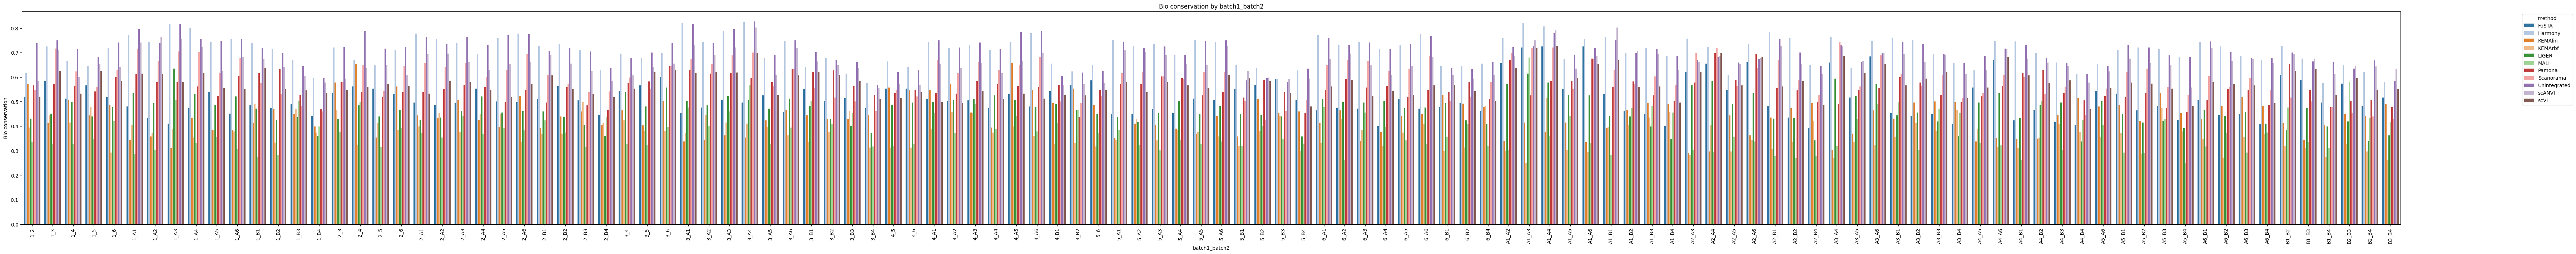

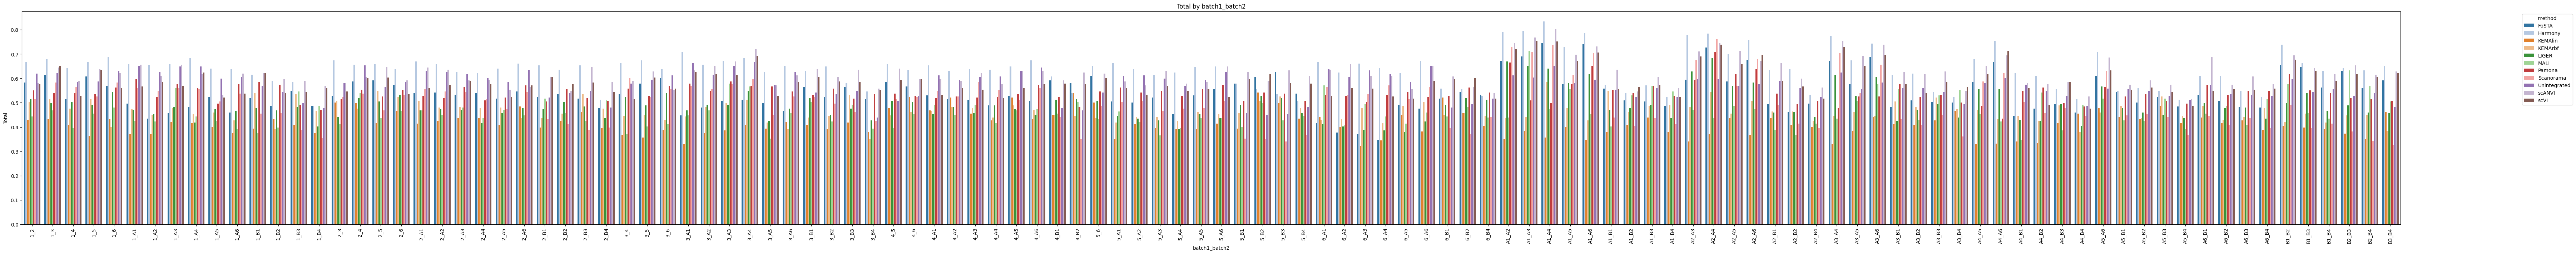

In [12]:
plot_metric_grouped_by(results_df, groupby_cols=["batch1_batch2", "method"], annotate=False, fig_len_factor=4)

In [8]:
results_df["batch1_batch2"] = results_df["batch1"] + "_" + results_df["batch2"]

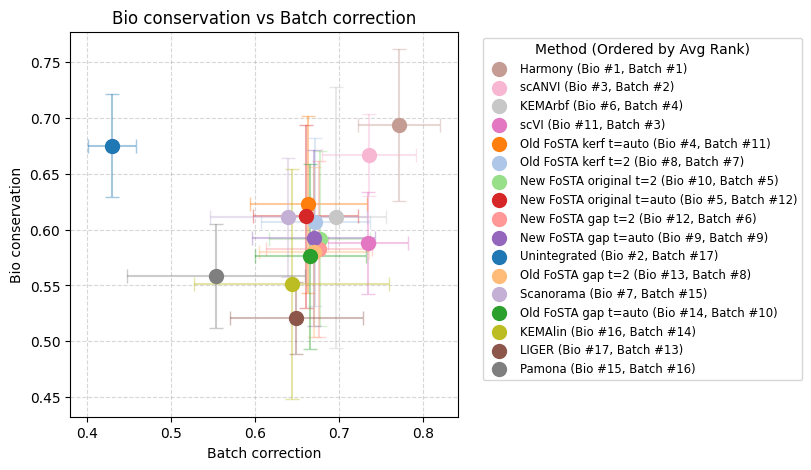

In [15]:
plot_bio_vs_batch_correction(results_df)

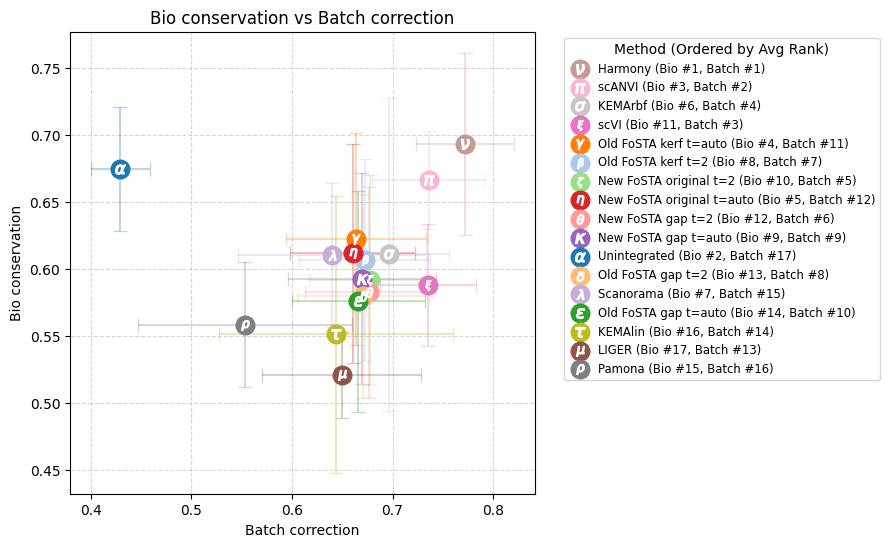

In [18]:
plot_bio_vs_batch_correction_markers(results_df)

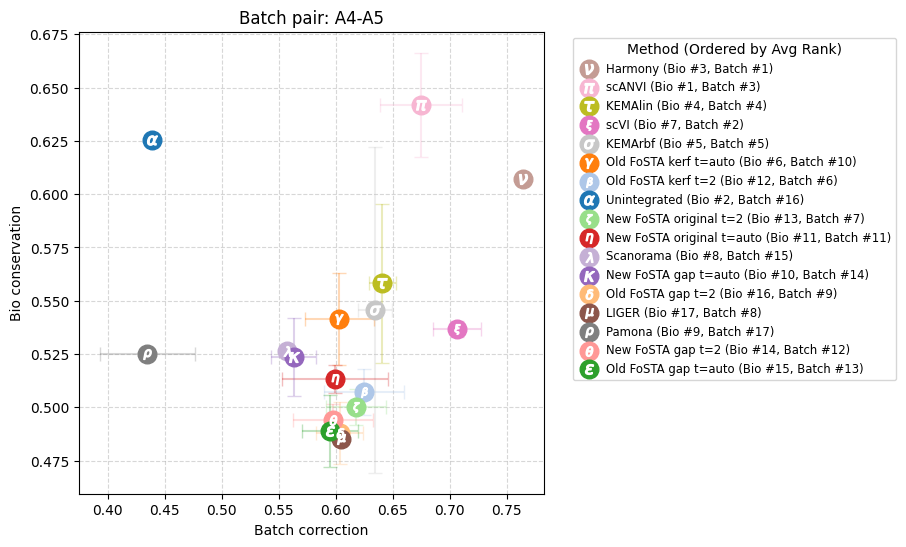

In [28]:
batch1 = "A4"
batch2 = "A5"
results_subset = results_df[(results_df["batch1"] == batch1) & (results_df["batch2"] == batch2)]
plot_bio_vs_batch_correction_markers(results_subset, title="Batch pair: {}-{}".format(batch1, batch2))

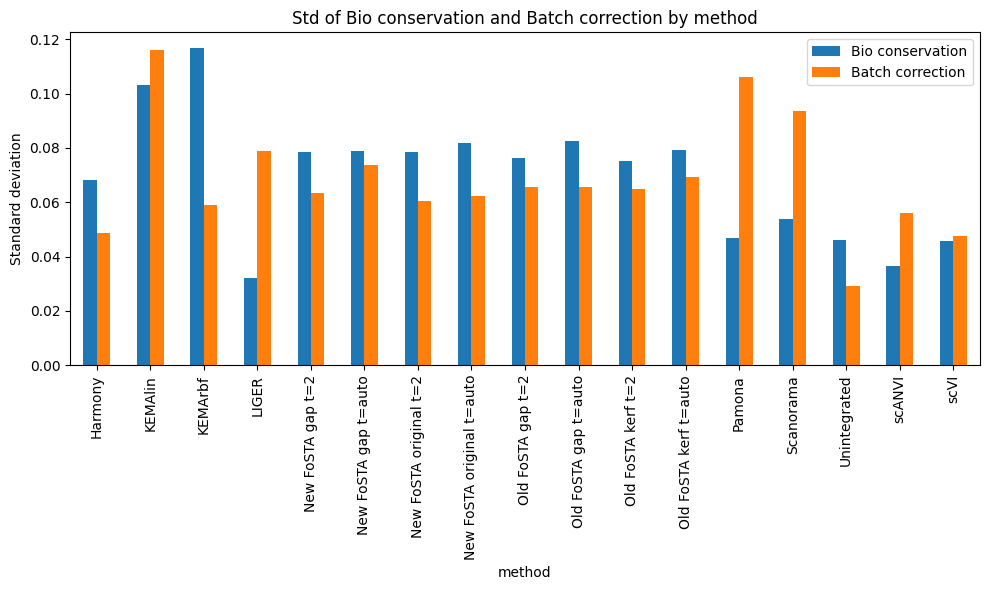

In [30]:
# bar plot of the std over bio conservation and batch correction for each method
std_df = (
    results_df.groupby("method")[["Bio conservation", "Batch correction"]]
    .std()
    .fillna(0)
)

ax = std_df.plot(kind="bar", figsize=(10, 6))
ax.set_ylabel("Standard deviation")
ax.set_title("Std of Bio conservation and Batch correction by method")
plt.tight_layout()
plt.show()

In [33]:
std_df = results_df.groupby(['method', 'batch1', 'batch2'])[["Bio conservation", "Batch correction"]].std()
std_df = std_df.fillna(0)


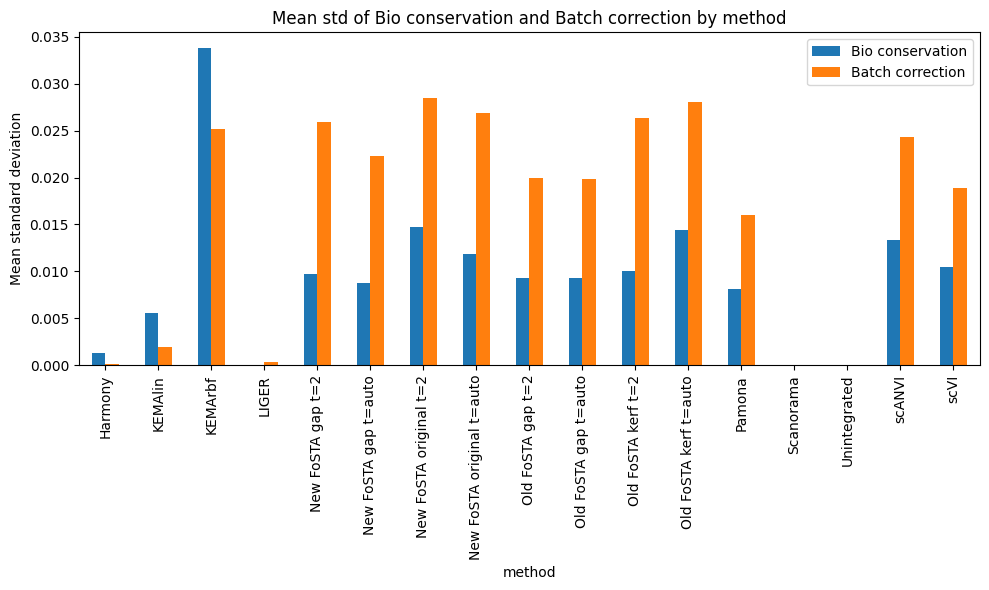

In [35]:
std_df.groupby("method")[["Bio conservation", "Batch correction"]].mean().plot(kind="bar", figsize=(10, 6))
plt.ylabel("Mean standard deviation")
plt.title("Mean std of Bio conservation and Batch correction by method")
plt.tight_layout()

In [27]:
results_df["batch_pair"] = f"{results_df['batch1']}_{results_df['batch2']}"
results_df["batch_pair"].unique()

array(['0      1\n1      1\n2      1\n3      1\n4      1\n      ..\n804    3\n805    3\n806    3\n807    3\n808    3\nName: batch1, Length: 756, dtype: int64_0      2\n1      2\n2      2\n3      2\n4      2\n      ..\n804    6\n805    6\n806    6\n807    6\n808    6\nName: batch2, Length: 756, dtype: object'],
      dtype=object)

In [28]:
results_df

,n_components,method,Isolated labels,Leiden NMI,Leiden ARI,KMeans NMI,KMeans ARI,Silhouette label,cLISI,BRAS,...,PCR comparison,Batch correction,Bio conservation,Total,cell_cycle_score,time,memory,batch1,batch2,batch_pair
0,2.0,Unintegrated,0.687804,0.853471,0.805380,0.699387,0.447650,0.615891,0.990031,0.669590,...,0.000000,0.505223,0.728517,0.639199,NaN,NaN,NaN,1,2,0 1\n1 1\n2 1\n3 1\n4 ...
1,2.0,FoSTA_PHATE_tauto,0.515022,0.496456,0.284032,0.547684,0.471374,0.513882,0.914289,0.293947,...,0.987903,0.674030,0.534677,0.590418,0.988055,115.056723,362.144176,1,2,0 1\n1 1\n2 1\n3 1\n4 ...
2,2.0,FoSTA_PHATE_t2,0.530315,0.492440,0.291186,0.495585,0.276569,0.504763,0.921057,0.282829,...,0.977223,0.647339,0.501702,0.559957,0.799613,56.858186,362.028246,1,2,0 1\n1 1\n2 1\n3 1\n4 ...
3,2.0,FoSTA_PHATE_OOB,0.462085,0.526053,0.262254,0.522416,0.224502,0.523978,0.928021,0.376374,...,0.989575,0.755772,0.492758,0.597964,0.589758,96.711996,344.720539,1,2,0 1\n1 1\n2 1\n3 1\n4 ...
4,2.0,FoSTA_PHATE_denseOT,0.474352,0.475784,0.259987,0.482023,0.281769,0.485581,0.919394,0.274881,...,0.957517,0.617160,0.482698,0.536483,0.462922,31.877904,361.995514,1,2,0 1\n1 1\n2 1\n3 1\n4 ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
804,2.0,scVI,0.977710,0.661020,0.443054,0.608231,0.381267,0.585880,0.996892,0.389344,...,0.215120,0.461964,0.664865,0.583705,0.603551,330.550792,29.814746,3,6,0 1\n1 1\n2 1\n3 1\n4 ...
805,2.0,scANVI,0.956204,0.669741,0.402544,0.728932,0.574414,0.667499,0.999949,0.386593,...,0.000000,0.424120,0.714183,0.598158,0.574335,330.149572,30.472469,3,6,0 1\n1 1\n2 1\n3 1\n4 ...
806,2.0,Pamona,0.985498,0.610185,0.333380,0.629437,0.383247,0.532343,0.999697,0.366192,...,0.890274,0.526029,0.639112,0.593879,0.605715,123.007847,1013.828086,3,6,0 1\n1 1\n2 1\n3 1\n4 ...
807,2.0,KEMArbf,0.477157,0.398519,0.161216,0.328617,0.152968,0.534493,0.918699,0.496073,...,0.000000,0.465248,0.424524,0.440813,0.511825,1.154086,4.892303,3,6,0 1\n1 1\n2 1\n3 1\n4 ...


# only consider batches within the same set

In [54]:
def get_set_of_batch(batch):
    if batch.startswith("A"):
        return "A"
    elif batch.startswith("B"):
        return "B"
    else:
        return "0"
    
results_df["same_batch_set"] = (results_df["batch1"].apply(get_set_of_batch) == results_df["batch2"].apply(get_set_of_batch))

In [58]:
same_batch_results_df = results_df.loc[results_df["same_batch_set"] == True]

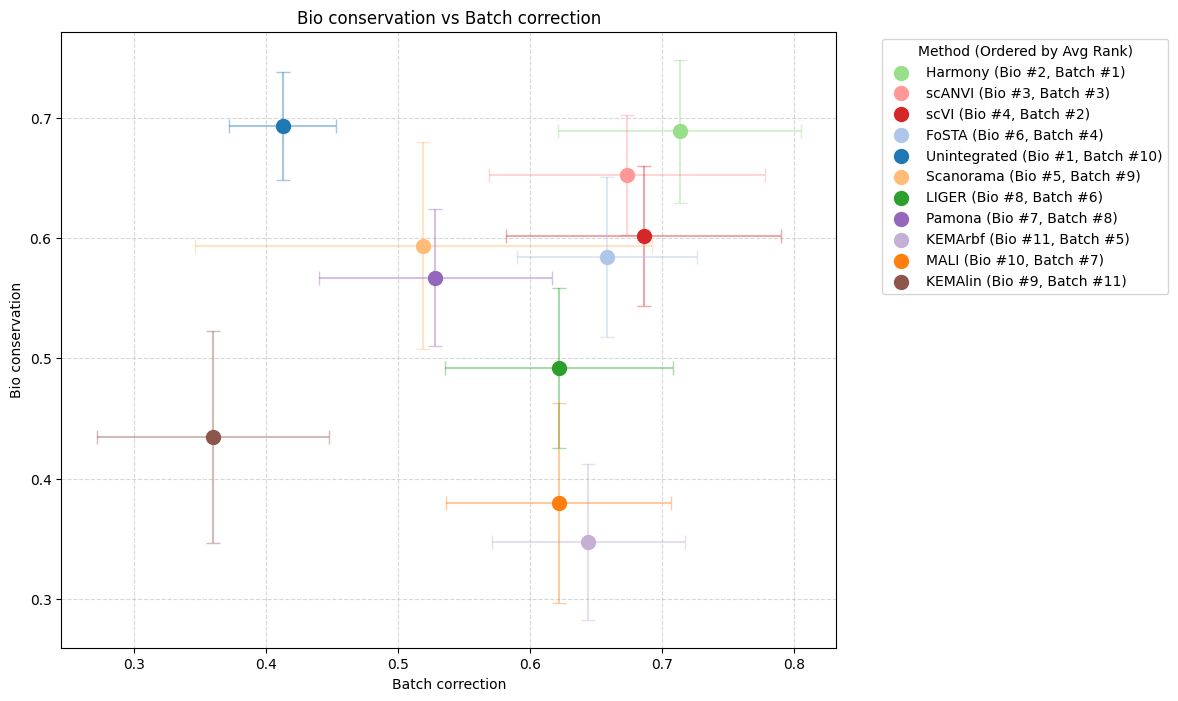

In [60]:
plot_bio_vs_batch_correction(same_batch_results_df)